# Intro
This notebook builds a GCN + GRU model to predict station demand at timestep T.
Unlike the flow-based model, edges between stations are defined by **geographic distance** (haversine).
Each station is connected to its K nearest neighbors, with edge weights computed via a Gaussian kernel.
Everything else — features, model architecture, training loop — is identical to the flow model.

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os

WORK_DIR = '/content/drive/MyDrive/DL_Project'
os.chdir(WORK_DIR)
print('cwd:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd: /content/drive/.shortcut-targets-by-id/1cv6g42seKHWos13nKtt695z3yVVUNFOn/DL_Project


In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [5]:
%pip install torch_geometric scikit-learn -q

In [6]:
import polars as pl
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn.conv import GCNConv

# Data Prep

In [7]:
cabi_demand = pl.read_parquet('data/cabi_master.parquet').with_columns([pl.col('start_station_id').cast(pl.Int64)])

# filter to stations with enough data (mirrors flow model exactly)
min_rows = 1000
station_counts = cabi_demand.group_by('start_station_id').agg(pl.len().alias('n_rows')).filter(pl.col('n_rows') >= min_rows)

valid_stations = set(station_counts['start_station_id'].to_list())

cabi_demand = cabi_demand.filter(pl.col('start_station_id').is_in(valid_stations))

In [8]:
cabi_demand.head(5)

start_station_id,year,started_at_15,demand,latitude,longitude,n_nearby_stations,n_bus_stops,n_metro_stations,n_commuter_bus,n_tourist_bus,n_carshare,n_hotels,n_museums,n_recreation,n_shopping,n_universities,n_schools,n_schools_private,n_parks,n_national_parks,m5_4_bike_,m5_5_sidew,m8_3_trail,m8_4_land_,m8_5_posit,m8_6_flood,m9_1_vacan,m9_2_stree,m9_3_polic,m9_4_fire_,m9_5_HIN,m6_5_resta,m6_6_liquo,m8_1_urban,total_popE,pop_maleE,pop_femaleE,median_ageE,median_hh_incomeE,in_low_stress_bikeshed,in_total_bikeshed,temp_f,precip_in,hour,minute,day_of_week,month,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos,date,is_holiday
i64,f64,"datetime[μs, UTC]",i32,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,date,i8
30200,2024.0,2023-02-01 15:15:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,38.3,0.0,15,15,3,2,5,0,0.433884,-0.900969,0.568065,0.822984,2023-02-01,0
30200,2024.0,2023-02-01 16:15:00 UTC,0,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,38.1,0.0,16,15,3,2,5,0,0.433884,-0.900969,0.568065,0.822984,2023-02-01,0
30200,2024.0,2023-02-01 16:30:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,38.1,0.0,16,30,3,2,5,0,0.433884,-0.900969,0.568065,0.822984,2023-02-01,0
30200,2024.0,2023-02-02 08:45:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,29.2,0.0,8,45,4,2,5,0,-0.433884,-0.900969,0.568065,0.822984,2023-02-02,0
30200,2024.0,2023-02-02 11:15:00 UTC,-1,38.894183,-77.023874,3.0,23,23,23,23,23,23,23,23,23,23,23,23,23,23,0.267225,0.96681,0.797589,0.0,0.889849,0.871931,0.932898,0.3994,0.999894,0.999894,0.763164,0.999894,0.000106,0.067244,1843.0,1084.0,759.0,41.8,198295.0,1,1,35.1,0.0,11,15,4,2,5,0,-0.433884,-0.900969,0.568065,0.822984,2023-02-02,0


In [9]:
# build station index mapper — sorted for deterministic alignment with distance adjacency
station_ids = (
    cabi_demand.select('start_station_id')
    .unique()
    .sort('start_station_id')
    .get_column('start_station_id')
    .to_list()
)

station_idx_mapper = {si: i for i, si in enumerate(station_ids)}
N = len(station_ids)
print(f'N stations: {N}')

N stations: 407


# Construct Distance Adjacency
We use haversine distance between stations to define edges.
Each station is connected to its K nearest neighbors.
Edge weights are computed with a Gaussian kernel using an adaptive sigma
(set to the mean k-NN distance across all stations), so weights adapt to
the actual density of the network rather than requiring manual tuning.

In [10]:
# extract one lat/lon per station, in the same sorted order as station_idx_mapper
station_coords = (
    cabi_demand
    .select(['start_station_id', 'latitude', 'longitude'])
    .unique(subset='start_station_id')
    .sort('start_station_id')
    .drop_nulls()
)

lat = station_coords['latitude'].to_numpy()
lon = station_coords['longitude'].to_numpy()
print(f'coords shape: {lat.shape}')

coords shape: (407,)


In [11]:
# vectorized haversine distance matrix (km)
lat_rad = np.radians(lat)
lon_rad = np.radians(lon)

dlat = lat_rad[:, None] - lat_rad[None, :]
dlon = lon_rad[:, None] - lon_rad[None, :]

R = 6371  # Earth radius in km
a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat_rad[:, None]) * np.cos(lat_rad[None, :]) * np.sin(dlon / 2) ** 2
)
D = 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

print(f'D shape: {D.shape}')
print(f'distance range: {D.min():.3f} – {D.max():.3f} km')

D shape: (407, 407)
distance range: 0.000 – 17.792 km


In [12]:
def build_knn_adjacency(D, k=5):
    n = D.shape[0]
    A = np.zeros_like(D)

    # compute adaptive sigma from mean k-NN distance across all stations
    knn_dists = []
    for i in range(n):
        neighbors = np.argsort(D[i])[1:k+1]
        knn_dists.append(D[i, neighbors])
    sigma = np.mean(knn_dists)
    print(f'adaptive sigma: {sigma:.4f} km')

    for i in range(n):
        neighbors = np.argsort(D[i])[1:k+1]
        A[i, neighbors] = np.exp(-(D[i, neighbors] ** 2) / (2 * sigma ** 2))

    A = np.maximum(A, A.T)  # make symmetric, no self-loops
    return A

A = build_knn_adjacency(D, k=5)

adaptive sigma: 0.5298 km


In [13]:
print(f'A shape: {A.shape}')
print(f'weight range: {A.min():.4f} – {A.max():.4f}')
print(f'edges per node: {(A > 0).sum(axis=1).mean():.1f} avg, {(A > 0).sum(axis=1).min()} min, {(A > 0).sum(axis=1).max()} max')
print(f'total edges: {(A > 0).sum()}')

A shape: (407, 407)
weight range: 0.0000 – 0.9996
edges per node: 6.1 avg, 5 min, 10 max
total edges: 2478


In [14]:
# convert dense adjacency to sparse edge_index + edge_attr tensors for GCNConv
rows, cols = np.where(A > 0)
edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
edge_data = torch.tensor(A[rows, cols], dtype=torch.float)

print(f'edge_index shape: {edge_index.shape}')
print(f'edge_data  shape: {edge_data.shape}')

edge_index shape: torch.Size([2, 2478])
edge_data  shape: torch.Size([2478])


## Build Feature Tensor from cabi_demand
Split features into static (station-level) and temporal (time-varying).

In [15]:
static_feat = [
    'n_bus_stops', 'n_metro_stations', 'n_commuter_bus', 'n_carshare',
    'n_hotels', 'n_parks', 'n_shopping', 'total_popE', 'median_hh_incomeE',
    'in_low_stress_bikeshed', 'latitude', 'longitude',
    'm5_4_bike_', 'm5_5_sidew', 'm8_3_trail', 'm8_1_urban',
]
time_feat = [
    'temp_f', 'precip_in',
    'hour', 'minute',
    'day_of_week_sin', 'day_of_week_cos',
    'week_of_year_sin', 'week_of_year_cos',
    'month',
]
all_feat = static_feat + time_feat

In [16]:
distinct_timesteps = (
    cabi_demand.select('started_at_15')
    .unique()
    .sort('started_at_15')
    .get_column('started_at_15')
    .to_list()
)
T = len(distinct_timesteps)
timestep_mapper = {t: i for i, t in enumerate(distinct_timesteps)}

In [17]:
F = len(all_feat)
x = np.zeros((N, T, F), dtype=np.float32)
y = np.zeros((N, T),    dtype=np.float32)

demand_selected = (
    cabi_demand
    .with_columns([pl.col('start_station_id').cast(pl.Int64)])
    .with_columns([
        pl.col('start_station_id').replace(station_idx_mapper).cast(pl.Int64).alias('node_idx'),
        pl.col('started_at_15').replace(timestep_mapper).cast(pl.Int64).alias('time_idx'),
    ])
    .select(['node_idx', 'time_idx', 'demand'] + all_feat)
    .drop_nulls()
)

node_idx = demand_selected['node_idx'].to_numpy().astype(np.int64)
time_idx = demand_selected['time_idx'].to_numpy().astype(np.int64)
feat_vals = demand_selected.select(all_feat).to_numpy()
demand_vals = demand_selected['demand'].to_numpy()

x[node_idx, time_idx, :] = feat_vals
y[node_idx, time_idx] = demand_vals
x = torch.tensor(x, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float)

import gc
del demand_selected
gc.collect()

78

In [18]:
print('x shape:', x.shape)
print('y shape:', y.shape)

x shape: torch.Size([407, 148271, 25])
y shape: torch.Size([407, 148271])


In [19]:
# per-station active mask: True where the station was operational
station_active = cabi_demand.group_by('start_station_id').agg([
    pl.col('started_at_15').min().alias('first_seen'),
    pl.col('started_at_15').max().alias('last_seen'),
])

mask = torch.zeros((N, T), dtype=torch.bool)
for row in station_active.iter_rows(named=True):
    nidx = station_idx_mapper[row['start_station_id']]
    t_start = timestep_mapper[row['first_seen']]
    t_end = timestep_mapper[row['last_seen']]
    mask[nidx, t_start:t_end+1] = True

print(f'Mask fill rate: {mask.float().mean():.2%}')

# done with raw data — free before scaling
del cabi_demand, station_active
gc.collect()

Mask fill rate: 91.31%


0

## Window Slicing
The model consumes a fixed-length sequence to predict ahead a horizon of steps.

In [20]:
# log-compress targets: sign(y) * log1p(|y|)
# maps [-20, 26] → [-3.0, 3.3] — compresses large spikes into a learnable range
# inverse at eval time: sign(pred) * (exp(abs(pred)) - 1)
y = y.sign() * torch.log1p(y.abs())
print(f'y range after log transform: {y.min():.3f} – {y.max():.3f}')

y range after log transform: -3.526 – 3.761


In [21]:
class WindowDataset(Dataset):
    def __init__(self, x, y, mask, seq_len, horizon):
        self.x = x
        self.y = y
        self.mask = mask
        self.seq_len = seq_len
        self.horizon = horizon
        self.n_windows = x.shape[1] - seq_len - horizon + 1

    def __len__(self):
        return self.n_windows

    def __getitem__(self, idx):
        x_win = self.x[:, idx : idx + self.seq_len, :]
        y_win = self.y[:, idx + self.seq_len : idx + self.seq_len + self.horizon]
        m_win = self.mask[:, idx + self.seq_len : idx + self.seq_len + self.horizon]
        return x_win, y_win, m_win

## Train / Val / Test Split
Sequential 70/15/15 split — no shuffling to avoid data leakage into the GRU.

In [22]:
from sklearn.preprocessing import StandardScaler
import joblib

seq_len = 48
predict_horizon = 4

T_full = x.shape[1]
train_end = int(T_full * 0.70)
val_end = int(T_full * 0.85)

# fit scaler only on active training cells
x_train_slice = x[:, :train_end, :]
mask_train = mask[:, :train_end]
x_train_valid = x_train_slice[mask_train]

scaler = StandardScaler()
scaler.fit(x_train_valid.numpy())
del x_train_slice, x_train_valid
gc.collect()

# in-place scaling — avoids creating a second full copy of x (~6 GB)
x_np = x.numpy()                                        # zero-copy view
scaler.transform(x_np.reshape(-1, F), copy=False)       # writes back into x_np in-place
x = torch.from_numpy(x_np)

joblib.dump(scaler, 'feature_scaler_dist.pkl')

train_dataset = WindowDataset(
    x[:, :train_end, :],
    y[:, :train_end],
    mask[:, :train_end],
    seq_len, predict_horizon
)
val_dataset = WindowDataset(
    x[:, train_end:val_end, :],
    y[:, train_end:val_end],
    mask[:, train_end:val_end],
    seq_len, predict_horizon
)
test_dataset = WindowDataset(
    x[:, val_end:, :],
    y[:, val_end:],
    mask[:, val_end:],
    seq_len, predict_horizon
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=0)
val_loader = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

# Modeling
Identical architecture to the flow model — only the graph structure changes.

Input --> GCNConv + Skip --> GCNConv + Residual --> GRU --> Linear

In [23]:
class DistGCN_GRU(nn.Module):
    def __init__(self, in_features, hidden_dim, horizon, num_nodes, gru_layers=2, dropout=0.2):
        super().__init__()
        self.in_features = in_features
        self.hidden_dim = hidden_dim
        self.horizon = horizon
        self.num_nodes = num_nodes
        self.gru_layers = gru_layers

        self.gcn = GCNConv(in_features, hidden_dim, add_self_loops=False)
        self.gcn_2 = GCNConv(hidden_dim,  hidden_dim, add_self_loops=False)
        self.skip_connection_layer = nn.Linear(in_features, hidden_dim)
        self.gru = nn.GRU(input_size=hidden_dim, hidden_size=hidden_dim,
                            num_layers=gru_layers,
                            dropout=dropout if gru_layers > 1 else 0.0,
                            batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, horizon)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index, edge_attr=None):
        batch_size, N, seq_len, F = x.shape

        n_graphs = batch_size * seq_len
        E = edge_index.size(1)
        offsets = torch.arange(n_graphs, device=x.device) * N
        batched_edge_index = edge_index.unsqueeze(0).repeat(n_graphs, 1, 1)
        batched_edge_index = batched_edge_index + offsets.view(n_graphs, 1, 1)
        batched_edge_index = batched_edge_index.permute(1, 0, 2).reshape(2, n_graphs * E)

        batched_edge_attr = edge_attr.repeat(n_graphs) if edge_attr is not None else None

        x_flat = x.permute(0, 2, 1, 3).reshape(n_graphs * N, F)

        gcn_out = self.gcn(x_flat, batched_edge_index, batched_edge_attr)
        skip = self.skip_connection_layer(x_flat)
        h = self.relu(gcn_out + skip)

        gcn2_out = self.gcn_2(h, batched_edge_index, batched_edge_attr)
        h = self.relu(gcn2_out + h)

        h = h.reshape(batch_size, seq_len, N, self.hidden_dim)
        h = h.permute(0, 2, 1, 3).reshape(batch_size * N, seq_len, self.hidden_dim)

        gru_out, h_n = self.gru(h)
        out = self.output_layer(h_n[-1])
        out = out.reshape(batch_size, N, self.horizon)
        return out

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DistGCN_GRU(
    in_features=F,
    hidden_dim=128,
    horizon=predict_horizon,
    num_nodes=N,
).to(device)
print(model)

DistGCN_GRU(
  (gcn): GCNConv(25, 128)
  (gcn_2): GCNConv(128, 128)
  (skip_connection_layer): Linear(in_features=25, out_features=128, bias=True)
  (gru): GRU(128, 128, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=128, out_features=4, bias=True)
  (relu): ReLU()
)


# Training Loop

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

NONZERO_WEIGHT = 50.0

def masked_weighted_l1(pred, target, mask, nonzero_weight=NONZERO_WEIGHT):
    mask = mask.to(pred.device)
    weights = torch.where(target != 0, nonzero_weight, 1.0)
    weights = weights * mask.float()
    abs_err = (pred - target).abs()
    return (weights * abs_err).sum() / weights.sum().clamp(min=1.0)

edge_index = edge_index.to(device)
edge_data = edge_data.to(device)
print(f'edge_index shape: {edge_index.shape}')
print(f'edge_data  shape: {edge_data.shape}')

edge_index shape: torch.Size([2, 2478])
edge_data  shape: torch.Size([2478])


In [ ]:
from tqdm.notebook import tqdm

epochs = 10
best_val_loss = float('inf')
CKPT = 'best_model_dist.pt'

epoch_bar = tqdm(range(epochs), desc='Training', unit='epoch')
for epoch in epoch_bar:
    model.train()
    training_loss = 0.0
    train_bar = tqdm(train_loader, desc=f'  Epoch {epoch+1:02d} Train', leave=False, unit='batch')

    for x_b, y_b, m_b in train_bar:
        x_b, y_b, m_b = x_b.to(device), y_b.to(device), m_b.to(device)
        optimizer.zero_grad()
        pred = model(x_b, edge_index, edge_data)
        loss = masked_weighted_l1(pred, y_b, m_b)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()
        train_bar.set_postfix(loss=f'{loss.item():.4f}')

    training_loss /= len(train_loader)

    model.eval()
    validation_loss = 0.0
    val_bar = tqdm(val_loader, desc=f'  Epoch {epoch+1:02d} Val  ', leave=False, unit='batch')

    with torch.no_grad():
        for x_b, y_b, m_b in val_bar:
            x_b, y_b, m_b = x_b.to(device), y_b.to(device), m_b.to(device)
            pred = model(x_b, edge_index, edge_data)
            loss = masked_weighted_l1(pred, y_b, m_b)
            validation_loss += loss.item()

    validation_loss /= len(val_loader)
    scheduler.step(validation_loss)

    if validation_loss < best_val_loss:
        best_val_loss = validation_loss
        torch.save(model.state_dict(), CKPT)
        saved = 'saved!'
    else:
        saved = ''

    tqdm.write(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"LR: {optimizer.param_groups[0]['lr']:.1e} | "
        f"Train: {training_loss:.4f} | "
        f"Val: {validation_loss:.4f} | "
        f"Best: {best_val_loss:.4f} {saved}"
    )

print(f'Best Val Loss: {best_val_loss:.4f}')

Training:   0%|          | 0/10 [00:00<?, ?epoch/s]

  Epoch 01 Train:   0%|          | 0/3242 [00:00<?, ?batch/s]

  Epoch 01 Val  :   0%|          | 0/694 [00:00<?, ?batch/s]

Epoch 01/10 | LR: 1.0e-03 | Train: 0.6952 | Val: 0.6848 | Best: 0.6848 saved!


  Epoch 02 Train:   0%|          | 0/3242 [00:00<?, ?batch/s]

...

  Epoch 09 Val  :   0%|          | 0/694 [00:00<?, ?batch/s]

Epoch 09/10 | LR: 1.0e-03 | Train: 0.6431 | Val: 0.6560 | Best: 0.6560 saved!


  Epoch 10 Train:   0%|          | 0/3242 [00:00<?, ?batch/s]

  Epoch 10 Val  :   0%|          | 0/694 [00:00<?, ?batch/s]

Epoch 10/10 | LR: 1.0e-03 | Train: 0.6424 | Val: 0.6548 | Best: 0.6548 saved!
Best Val Loss: 0.6548


In [ ]:
# === FINETUNE 1 EPOCH WITH WEIGHTED MSE + DIAGNOSTICS ===

import numpy as np
from scipy.stats import pearsonr

# ---- 1. Load checkpoint ----
# CKPT = "best_model_dist.pt"
# CKPT = "mse_finetune_epoch1.pt"
CKPT = "mse_finetune_alpha4_epoch1.pt"
model.load_state_dict(torch.load(CKPT, map_location=device))
model.to(device)
model.train()

print("Loaded checkpoint and starting 1-epoch finetune...")

# ---- 2. Define new loss ----
# def masked_weighted_mse(pred, target, mask, alpha=2.0):
#     mask = mask.to(pred.device)
#     weight = 1.0 + alpha * target.abs()
#     loss = (pred - target) ** 2 * weight
#     return loss[mask].mean()
# def masked_weighted_mse(pred, target, mask, alpha=4.0):
#     mask = mask.to(pred.device)
#     weight = 1.0 + alpha * target.abs()
#     loss = (pred - target) ** 2 * weight
#     return loss[mask].mean()
def masked_weighted_mse(pred, target, mask, alpha=8.0):
    mask = mask.to(pred.device)
    weight = 1.0 + alpha * target.abs()
    loss = (pred - target) ** 2 * weight
    return loss[mask].mean()

# ---- 3. One epoch of training ----
for x_b, y_b, m_b in train_loader:
    x_b, y_b, m_b = x_b.to(device), y_b.to(device), m_b.to(device)
    optimizer.zero_grad()
    pred = model(x_b, edge_index, edge_data)
    loss = masked_weighted_mse(pred, y_b, m_b)
    loss.backward()
    optimizer.step()

print("Finished 1 epoch of finetuning.")

# ---- 4. Evaluate ----
model.eval()

all_preds, all_targets, all_masks = [], [], []
with torch.no_grad():
    for x_b, y_b, m_b in test_loader:
        x_b = x_b.to(device)
        pred = model(x_b, edge_index, edge_data).cpu()
        all_preds.append(pred)
        all_targets.append(y_b)
        all_masks.append(m_b)

preds = torch.cat(all_preds, dim=0)
targets = torch.cat(all_targets, dim=0)
masks = torch.cat(all_masks, dim=0)

# ---- 5. Inverse log transform (since training used log targets) ----
def inv_log_transform(t):
    return t.sign() * (t.abs().exp() - 1)

preds_raw = inv_log_transform(preds)
targets_raw = inv_log_transform(targets)

preds_flat = preds_raw[masks].numpy()
targets_flat = targets_raw[masks].numpy()

# ---- 6. Diagnostics ----
nz = targets_flat != 0

print("\n=== Diagnostics ===")
print("pred min/max:", preds_flat.min(), preds_flat.max())
print("target min/max:", targets_flat.min(), targets_flat.max())

print("\npred quantiles:", np.quantile(preds_flat, [.01,.05,.25,.5,.75,.95,.99]))
print("target quantiles:", np.quantile(targets_flat, [.01,.05,.25,.5,.75,.95,.99]))

print("\nMAE (all):", np.abs(preds_flat - targets_flat).mean())
print("MAE (nonzero):", np.abs(preds_flat[nz] - targets_flat[nz]).mean())

if nz.sum() > 10:
    corr, _ = pearsonr(preds_flat[nz], targets_flat[nz])
    print("Corr (nonzero):", corr)

# ---- 7. Save finetuned model ----
# torch.save(model.state_dict(), "mse_finetune_epoch1.pt")
# print("\nSaved finetuned model as mse_finetune_epoch1.pt")
# torch.save(model.state_dict(), "mse_finetune_alpha4_epoch1.pt")
# print("\nSaved finetuned model as mse_finetune_alpha4_epoch1.pt")
torch.save(model.state_dict(), "mse_finetune_alpha8_epoch1.pt")
print("\nSaved finetuned model as mse_finetune_alpha8_epoch1.pt")

Loaded checkpoint and starting 1-epoch finetune...
Finished 1 epoch of finetuning.

=== Diagnostics ===
pred min/max: -4.8736906 4.6525
target min/max: -20.000002 26.000002

pred quantiles: [-0.97443529 -0.41108896 -0.05814445  0.00905931  0.0660882   0.36688997
  0.99966606]
target quantiles: [-3. -1.  0.  0.  0.  1.  3.]

MAE (all): 0.41675535
MAE (nonzero): 1.3386064
Corr (nonzero): 0.33327463

Saved finetuned model as mse_finetune_alpha8_epoch1.pt


# Diagnostics

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

CKPT = "mse_finetune_alpha8_epoch1.pt"  # or your chosen best single-stage checkpoint
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()

all_preds, all_targets, all_masks = [], [], []

with torch.no_grad():
    for x_b, y_b, m_b in test_loader:
        x_b = x_b.to(device)
        pred = model(x_b, edge_index, edge_data).cpu()
        all_preds.append(pred)
        all_targets.append(y_b)
        all_masks.append(m_b)

preds   = torch.cat(all_preds, dim=0)
targets = torch.cat(all_targets, dim=0)
masks   = torch.cat(all_masks, dim=0)

def inv_log_transform(t):
    return t.sign() * (t.abs().exp() - 1)

preds_raw   = inv_log_transform(preds)
targets_raw = inv_log_transform(targets)

preds_flat   = preds_raw[masks].numpy()
targets_flat = targets_raw[masks].numpy()

print(f'Evaluating on {len(preds_flat):,} active (station, timestep) pairs')
print(f'pred min/max:   {preds_flat.min():.4f}  {preds_flat.max():.4f}')
print(f'target min/max: {targets_flat.min():.4f}  {targets_flat.max():.4f}')

nz       = targets_flat != 0
mae_all  = np.abs(preds_flat - targets_flat).mean()
mae_nz   = np.abs(preds_flat[nz] - targets_flat[nz]).mean()
rmse_all = np.sqrt(((preds_flat - targets_flat) ** 2).mean())
pcp_all  = (preds_flat.round() == targets_flat).mean()
pcp_nz   = (preds_flat[nz].round() == targets_flat[nz]).mean()

actual_trip    = targets_flat != 0
predicted_trip = preds_flat.round() != 0
pptt = (predicted_trip == actual_trip).mean()

print(f'MAE  (all):      {mae_all:.4f}')
print(f'MAE  (nonzero):  {mae_nz:.4f}')
print(f'RMSE (all):      {rmse_all:.4f}')
print(f'PCP  (all):      {pcp_all:.4f}')
print(f'PCP  (nonzero):  {pcp_nz:.4f}')
print(f'PPTT:            {pptt:.4f}')

if nz.sum() > 10:
    corr, _ = pearsonr(preds_flat[nz], targets_flat[nz])
    print(f'Corr (nonzero):  {corr:.4f}')

dir_acc_all = (np.sign(preds_flat.round()) == np.sign(targets_flat)).mean()
dir_acc_nz  = (np.sign(preds_flat[nz].round()) == np.sign(targets_flat[nz])).mean()
print(f'Direction acc (all):     {dir_acc_all:.4f}')
print(f'Direction acc (nonzero): {dir_acc_nz:.4f}')

Evaluating on 35,441,038 active (station, timestep) pairs
pred min/max:   -4.8737  4.6525
target min/max: -20.0000  26.0000
MAE  (all):      0.4168
MAE  (nonzero):  1.3386
RMSE (all):      0.8190
PCP  (all):      0.7388
PCP  (nonzero):  0.0634
PPTT:            0.7601
Corr (nonzero):  0.3333
Direction acc (all):     0.7528
Direction acc (nonzero): 0.1204


In [29]:
import os
import pandas as pd
from datetime import datetime

metrics = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model": "dist_1_stage_dist",
    "ckpt": CKPT,

    "pred_min": float(preds_flat.min()),
    "pred_max": float(preds_flat.max()),
    "target_min": float(targets_flat.min()),
    "target_max": float(targets_flat.max()),

    "mae_all": float(mae_all),
    "mae_nonzero": float(mae_nz),
    "rmse_all": float(rmse_all),
    "pcp_all": float(pcp_all),
    "pcp_nonzero": float(pcp_nz),
    "pptt": float(pptt),
    "corr_nonzero": float(corr) if nz.sum() > 10 else None,
    "dir_acc_all": float(dir_acc_all),
    "dir_acc_nonzero": float(dir_acc_nz),
}

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "1_stage_dist_model_alpha8_metrics.csv")

df_new = pd.DataFrame([metrics])

if os.path.exists(csv_path):
    df_old = pd.read_csv(csv_path)
    df_all = pd.concat([df_old, df_new], ignore_index=True)
else:
    df_all = df_new

df_all.to_csv(csv_path, index=False)

print(f"Saved metrics to {csv_path}")

Saved metrics to outputs/1_stage_dist_model_alpha8_metrics.csv


Saved plot to outputs/pred_vs_actual_dist_1stage_alpha8.png


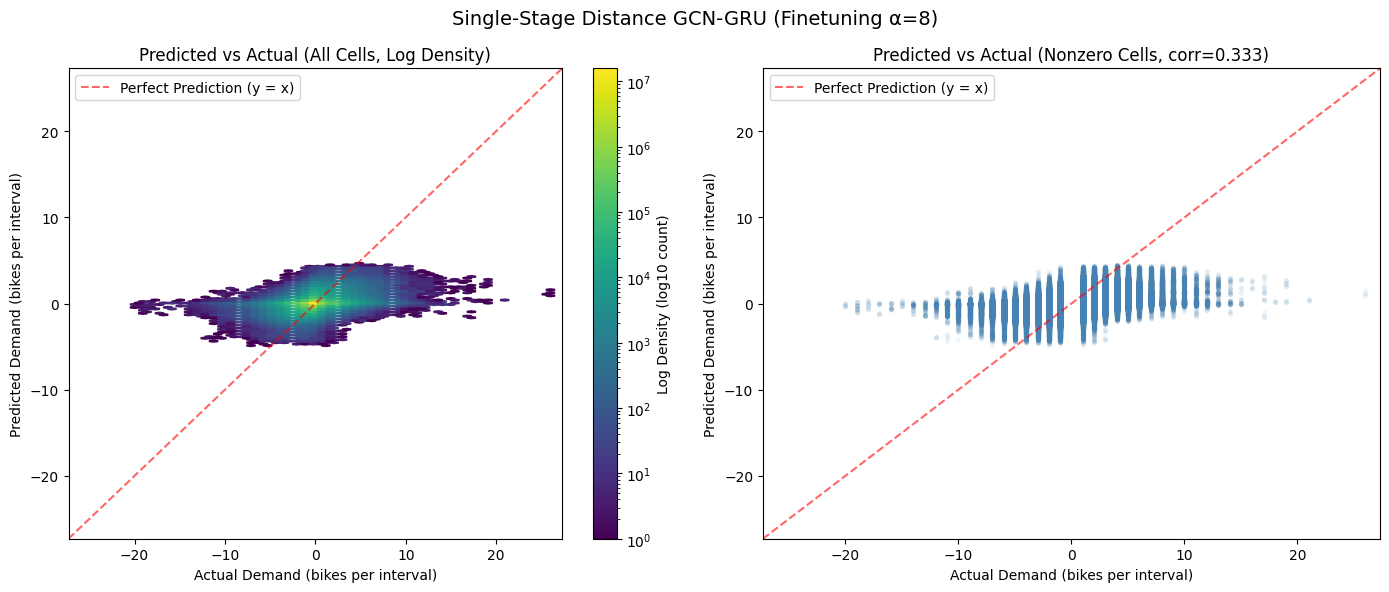

In [36]:
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# overall title
fig.suptitle(
    'Single-Stage Distance GCN-GRU (Finetuning α=8)',
    fontsize=14
)

# ---- All cells ----
ax = axes[0]
hb = ax.hexbin(targets_flat, preds_flat, gridsize=50, bins="log", cmap="viridis", mincnt=1)

lim = max(abs(targets_flat).max(), abs(preds_flat).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], "r--", alpha=0.6, label="Perfect Prediction (y = x)")

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xlabel("Actual Demand (bikes per interval)")
ax.set_ylabel("Predicted Demand (bikes per interval)")
ax.set_title("Predicted vs Actual (All Cells, Log Density)", fontsize=12)
ax.legend(loc="upper left")

plt.colorbar(hb, ax=ax, label="Log Density (log10 count)")

# ---- Nonzero cells ----
ax = axes[1]

ax.scatter(targets_flat[nz], preds_flat[nz], alpha=0.05, s=8, color="steelblue")

nz_lim = max(abs(targets_flat[nz]).max(), abs(preds_flat[nz]).max()) * 1.05
ax.plot([-nz_lim, nz_lim], [-nz_lim, nz_lim], "r--", alpha=0.6, label="Perfect Prediction (y = x)")

ax.set_xlim(-nz_lim, nz_lim)
ax.set_ylim(-nz_lim, nz_lim)

ax.set_xlabel("Actual Demand (bikes per interval)")
ax.set_ylabel("Predicted Demand (bikes per interval)")

corr, _ = pearsonr(preds_flat[nz], targets_flat[nz])
ax.set_title(f"Predicted vs Actual (Nonzero Cells, corr={corr:.3f})", fontsize=12)
ax.legend(loc="upper left")

plt.tight_layout()

save_path = os.path.join(out_dir, "pred_vs_actual_dist_1stage_alpha8.png")
plt.savefig(save_path, dpi=120, bbox_inches="tight")

print(f"Saved plot to {save_path}")
plt.show()

Saved plot to outputs/residuals_dist_1stage_alpha8.png


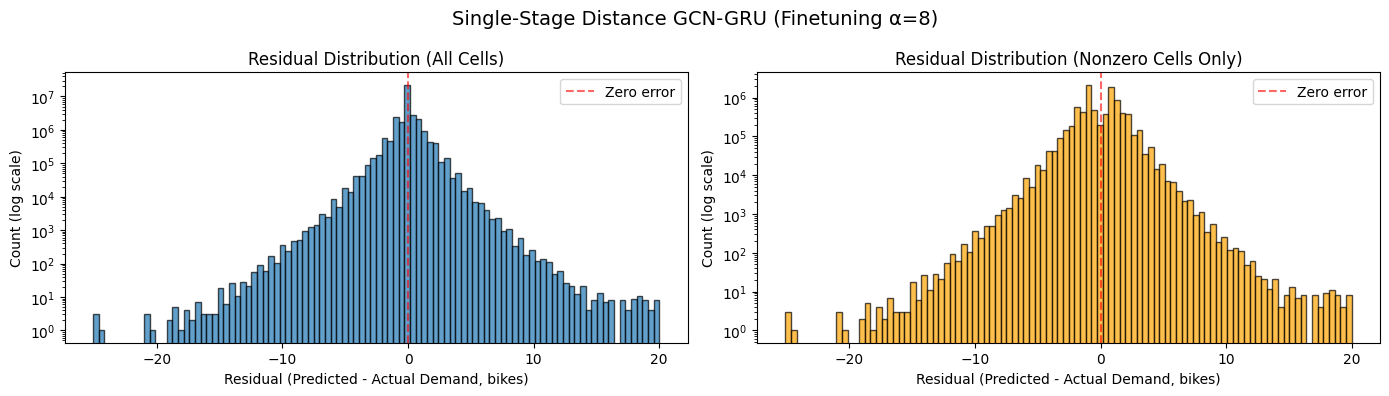

In [35]:
import os
import matplotlib.pyplot as plt

out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

residuals = preds_flat - targets_flat

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# overall title (model info goes here)
fig.suptitle(
    'Single-Stage Distance GCN-GRU (Finetuning α=8)',
    fontsize=14
)

# ---- All cells ----
axes[0].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Residual (Predicted - Actual Demand, bikes)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Residual Distribution (All Cells)', fontsize=12)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6, label='Zero error')
axes[0].set_yscale('log')
axes[0].legend()

# ---- Nonzero cells ----
axes[1].hist(residuals[nz], bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Residual (Predicted - Actual Demand, bikes)')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Residual Distribution (Nonzero Cells Only)', fontsize=12)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6, label='Zero error')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()

save_path = os.path.join(out_dir, "residuals_dist_1stage_alpha8.png")
plt.savefig(save_path, dpi=120, bbox_inches='tight')

print(f"Saved plot to {save_path}")
plt.show()

In [ ]:
print("pred min/max:", preds_flat.min(), preds_flat.max())
print("target min/max:", targets_flat.min(), targets_flat.max())

for q in [0, .01, .05, .25, .5, .75, .95, .99, 1]:
    print(q, "pred", np.quantile(preds_flat, q), "target", np.quantile(targets_flat, q))

print("target counts:")
print(dict(zip(*np.unique(targets_flat, return_counts=True))))

pred min/max: -1.1611083 2.5690422
target min/max: -20.000002 26.000002
0 pred -1.1611083 target -20.000002
0.01 pred -1.0036504 target -3.0
0.05 pred -0.99854267 target -1.0
0.25 pred -0.966105 target 0.0
0.5 pred -0.00013554096 target 0.0
0.75 pred 0.84936774 target 0.0
0.95 pred 0.9954537 target 1.0
0.99 pred 1.0026727 target 3.0
1 pred 2.5690422 target 26.000002
target counts:
{np.float32(-20.000002): np.int64(8), np.float32(-19.0): np.int64(24), np.float32(-18.0): np.int64(12), np.float32(-17.0): np.int64(12), np.float32(-16.0): np.int64(20), np.float32(-15.0): np.int64(12), np.float32(-14.000001): np.int64(40), np.float32(-13.000001): np.int64(60), np.float32(-11.999999): np.int64(116), np.float32(-11.0): np.int64(320), np.float32(-10.000001): np.int64(584), np.float32(-9.0): np.int64(1076), np.float32(-8.0): np.int64(2460), np.float32(-7.0): np.int64(5848), np.float32(-5.9999995): np.int64(13773), np.float32(-5.0): np.int64(35080), np.float32(-4.0): np.int64(94041), np.float32(-

In [ ]:
print("nonzero pred min/max:", preds_flat[nz].min(), preds_flat[nz].max())
print("nonzero target min/max:", targets_flat[nz].min(), targets_flat[nz].max())
print("nonzero target quantiles:", np.quantile(targets_flat[nz], [.01,.05,.25,.5,.75,.95,.99]))
print("nonzero pred quantiles:", np.quantile(preds_flat[nz], [.01,.05,.25,.5,.75,.95,.99]))

nonzero pred min/max: -1.1561885 2.5690422
nonzero target min/max: -20.000002 26.000002
nonzero target quantiles: [-4. -2. -1. -1.  1.  2.  4.]
nonzero pred quantiles: [-1.00590039e+00 -1.00065708e+00 -9.89643097e-01 -4.17113304e-04
  9.88312244e-01  9.98046637e-01  1.05996135e+00]


In [ ]:
for threshold in [1, 2, 3, 5, 10]:
    hi = np.abs(targets_flat) >= threshold
    print(
        f"|target| >= {threshold}:",
        "n=", hi.sum(),
        "mean |target|=", np.abs(targets_flat[hi]).mean(),
        "mean |pred|=", np.abs(preds_flat[hi]).mean(),
        "pred min/max=", preds_flat[hi].min(), preds_flat[hi].max()
    )

|target| >= 1: n= 8712097 mean |target|= 1.448503 mean |pred|= 0.20636533 pred min/max= -4.0424695 4.097395
|target| >= 2: n= 2522854 mean |target|= 2.5488024 mean |pred|= 0.2811947 pred min/max= -3.9852462 4.097395
|target| >= 3: n= 844333 mean |target|= 3.6398127 mean |pred|= 0.35938728 pred min/max= -3.9158688 4.097395
|target| >= 5: n= 125168 mean |target|= 5.793741 mean |pred|= 0.50083387 pred min/max= -3.8306708 4.097395
|target| >= 10: n= 2816 mean |target|= 11.237216 mean |pred|= 0.6727936 pred min/max= -3.522995 3.7520876


In [ ]:
preds_flat   = preds[masks].numpy()
targets_flat = targets[masks].numpy()

print("pred range:", preds_flat.min(), preds_flat.max())
print("target range:", targets_flat.min(), targets_flat.max())

print("pred quantiles:", np.quantile(preds_flat, [.01,.05,.25,.5,.75,.95,.99]))
print("target quantiles:", np.quantile(targets_flat, [.01,.05,.25,.5,.75,.95,.99]))

pred range: -1.617896 1.6287296
target range: -3.0445225 3.295837
pred quantiles: [-0.57064501 -0.26605454 -0.05399162 -0.01099926  0.02264214  0.20848477
  0.57618564]
target quantiles: [-1.38629436 -0.69314718  0.          0.          0.          0.69314718
  1.38629436]
